In [2]:
import os
import sqlite3
import pymysql
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gensim

# Atur style grafik biar cantik dan premium
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

# 1. Definisi path model
save_dir = "saved_models"
model_path = os.path.join(save_dir, "model")
lda_model_file = os.path.join(model_path, "lda_model.gensim")
dictionary_file = os.path.join(model_path, "dictionary.gensim")
bigram_file = os.path.join(model_path, "bigram_model.gensim")

# 2. Muat model
print("Memuat model LDA...")
lda_model = gensim.models.ldamodel.LdaModel.load(lda_model_file)
id2word = gensim.corpora.Dictionary.load(dictionary_file)
bigram_mod = None
if os.path.exists(bigram_file):
    bigram_mod = gensim.models.phrases.Phraser(gensim.models.phrases.Phrases.load(bigram_file))
    
# 3. Label topik yang umum dan profesional
topic_labels = {
    0: "Suasana Kafe & Kualitas Penyajian",
    1: "Konsep Keunikan & Menu Minuman",
    2: "Fasilitas Kerja (WFC) & Kenyamanan Tempat",
    3: "Fasilitas Pendukung & Area Berkumpul",
    4: "Daya Tarik Ambience & Menu Dessert",
    5: "Sistem Pemesanan & Menu Makanan Berat"
}
print("Sukses memuat semua dependensi model!")

Memuat model LDA...
Sukses memuat semua dependensi model!


In [3]:
# Sambungkan ke MySQL Laragon/XAMPP
print("Menghubungkan ke MySQL database...")
conn = pymysql.connect(
    host="localhost",
    user="root",
    password="",
    database="skripsi_db",
    charset="utf8mb4"
)
cursor = conn.cursor()

# 1. Perbesar batas GROUP_CONCAT di MySQL agar teks tidak terpotong!
cursor.execute("SET SESSION group_concat_max_len = 4294967295;")

# Ambil review gabungan per coffeeshop
query = """
    SELECT nama_tempat, GROUP_CONCAT(clean_review SEPARATOR ' ') 
    FROM reviews 
    WHERE clean_review IS NOT NULL AND clean_review != '' 
    GROUP BY nama_tempat
"""
cursor.execute(query)
db_data = cursor.fetchall()
conn.close()

# Hitung distribusi dan buat baris data untuk DataFrame
rows = []
for shop_name, all_reviews in db_data:
    tokens = all_reviews.split()
    if bigram_mod:
        tokens = bigram_mod[tokens]
    bow = id2word.doc2bow(tokens)
    
    # Ambil probabilitas topik dari model LDA (minimum_probability=0.0 agar lengkap)
    topic_distribution = lda_model.get_document_topics(bow, minimum_probability=0.0)
    
    # Susun ke dictionary baris
    row = {"Coffeeshop": shop_name}
    for topic_id, prob in topic_distribution:
        row[topic_labels[topic_id]] = float(prob) * 100 # Konversi ke persen (%)
    rows.append(row)

# Buat DataFrame Pandas
df = pd.DataFrame(rows)
df.set_index("Coffeeshop", inplace=True)

print(f"Berhasil membuat DataFrame Pandas dengan {df.shape[0]} Coffeeshop dan {df.shape[1]} Topik!")
df.head() # Menampilkan 5 data pertama dalam bentuk tabel interaktif


Menghubungkan ke MySQL database...
Berhasil membuat DataFrame Pandas dengan 30 Coffeeshop dan 6 Topik!


,Suasana Kafe & Kualitas Penyajian,Konsep Keunikan & Menu Minuman,Fasilitas Kerja (WFC) & Kenyamanan Tempat,Fasilitas Pendukung & Area Berkumpul,Daya Tarik Ambience & Menu Dessert,Sistem Pemesanan & Menu Makanan Berat
Coffeeshop,,,,,,
11:12 sebelasduabelaskopi,6.618010,7.722134,48.519418,7.363378,4.675758,25.101307
ADA APA DENGAN KOPI - AADK TLOGOMAS,6.905813,6.759742,48.208061,7.885823,5.016021,25.224537
Ada Apa Dengan Kopi (AADK) Bandung Malang - Coffee & Eatery,5.957454,8.020431,50.072372,7.654280,5.311526,22.983937
Amstirdam Coffee & Roastery,8.379310,10.789594,42.796367,6.026544,11.415020,20.593159
Bento Kopi UIN Malang,9.573070,5.929706,56.759304,5.898609,3.203804,18.635511


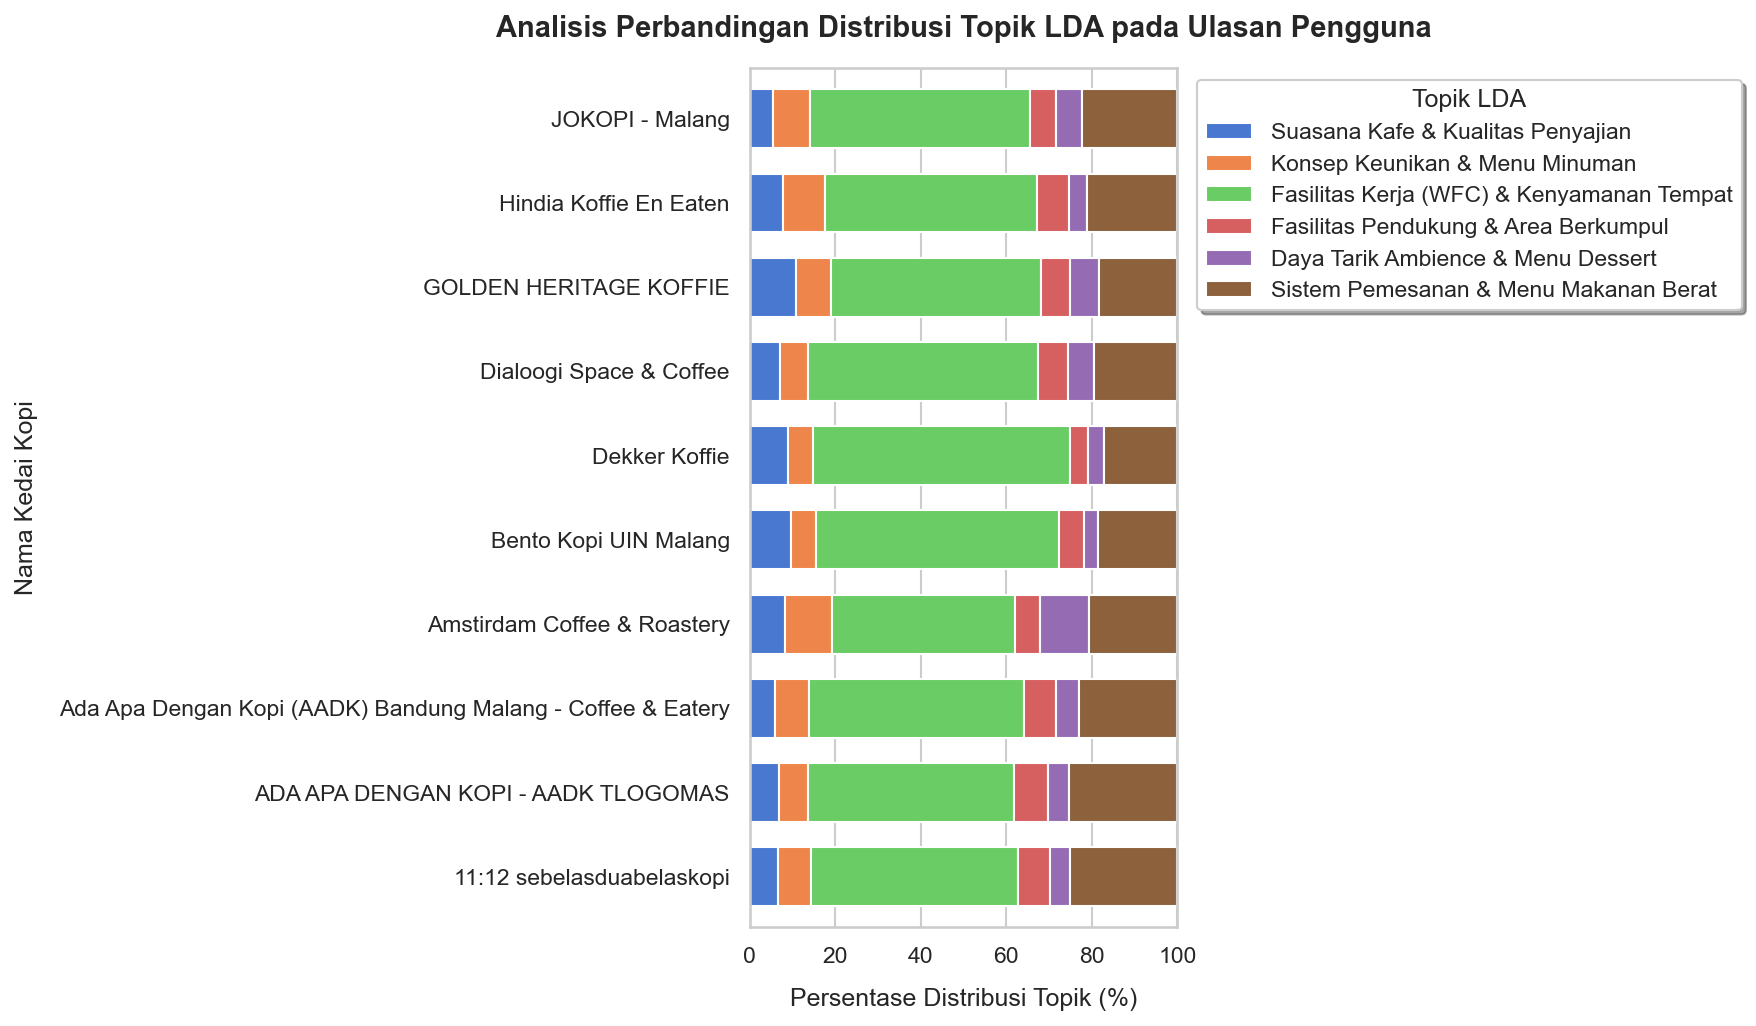

In [4]:
# Kita ambil 10 coffeeshop pertama agar grafik tidak terlalu padat
df_subset = df.head(10)

fig, ax = plt.subplots(figsize=(12, 7))

# Plot stacked bar chart dengan palet warna yang premium (muted / pastel-like)
colors = sns.color_palette("muted", 6)
df_subset.plot(kind="barh", stacked=True, color=colors, ax=ax, width=0.7)

# Konfigurasi judul dan label
ax.set_title("Analisis Perbandingan Distribusi Topik LDA pada Ulasan Pengguna", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Persentase Distribusi Topik (%)", fontsize=12, labelpad=10)
ax.set_ylabel("Nama Kedai Kopi", fontsize=12, labelpad=10)
ax.set_xlim(0, 100)

# Atur legenda agar rapi di luar grafik sebelah kanan
ax.legend(title="Topik LDA", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.savefig("perbandingan_topik_coffeeshop.png", dpi=300, bbox_inches='tight') # Simpan grafik dengan kualitas HD untuk bab 4
plt.show()


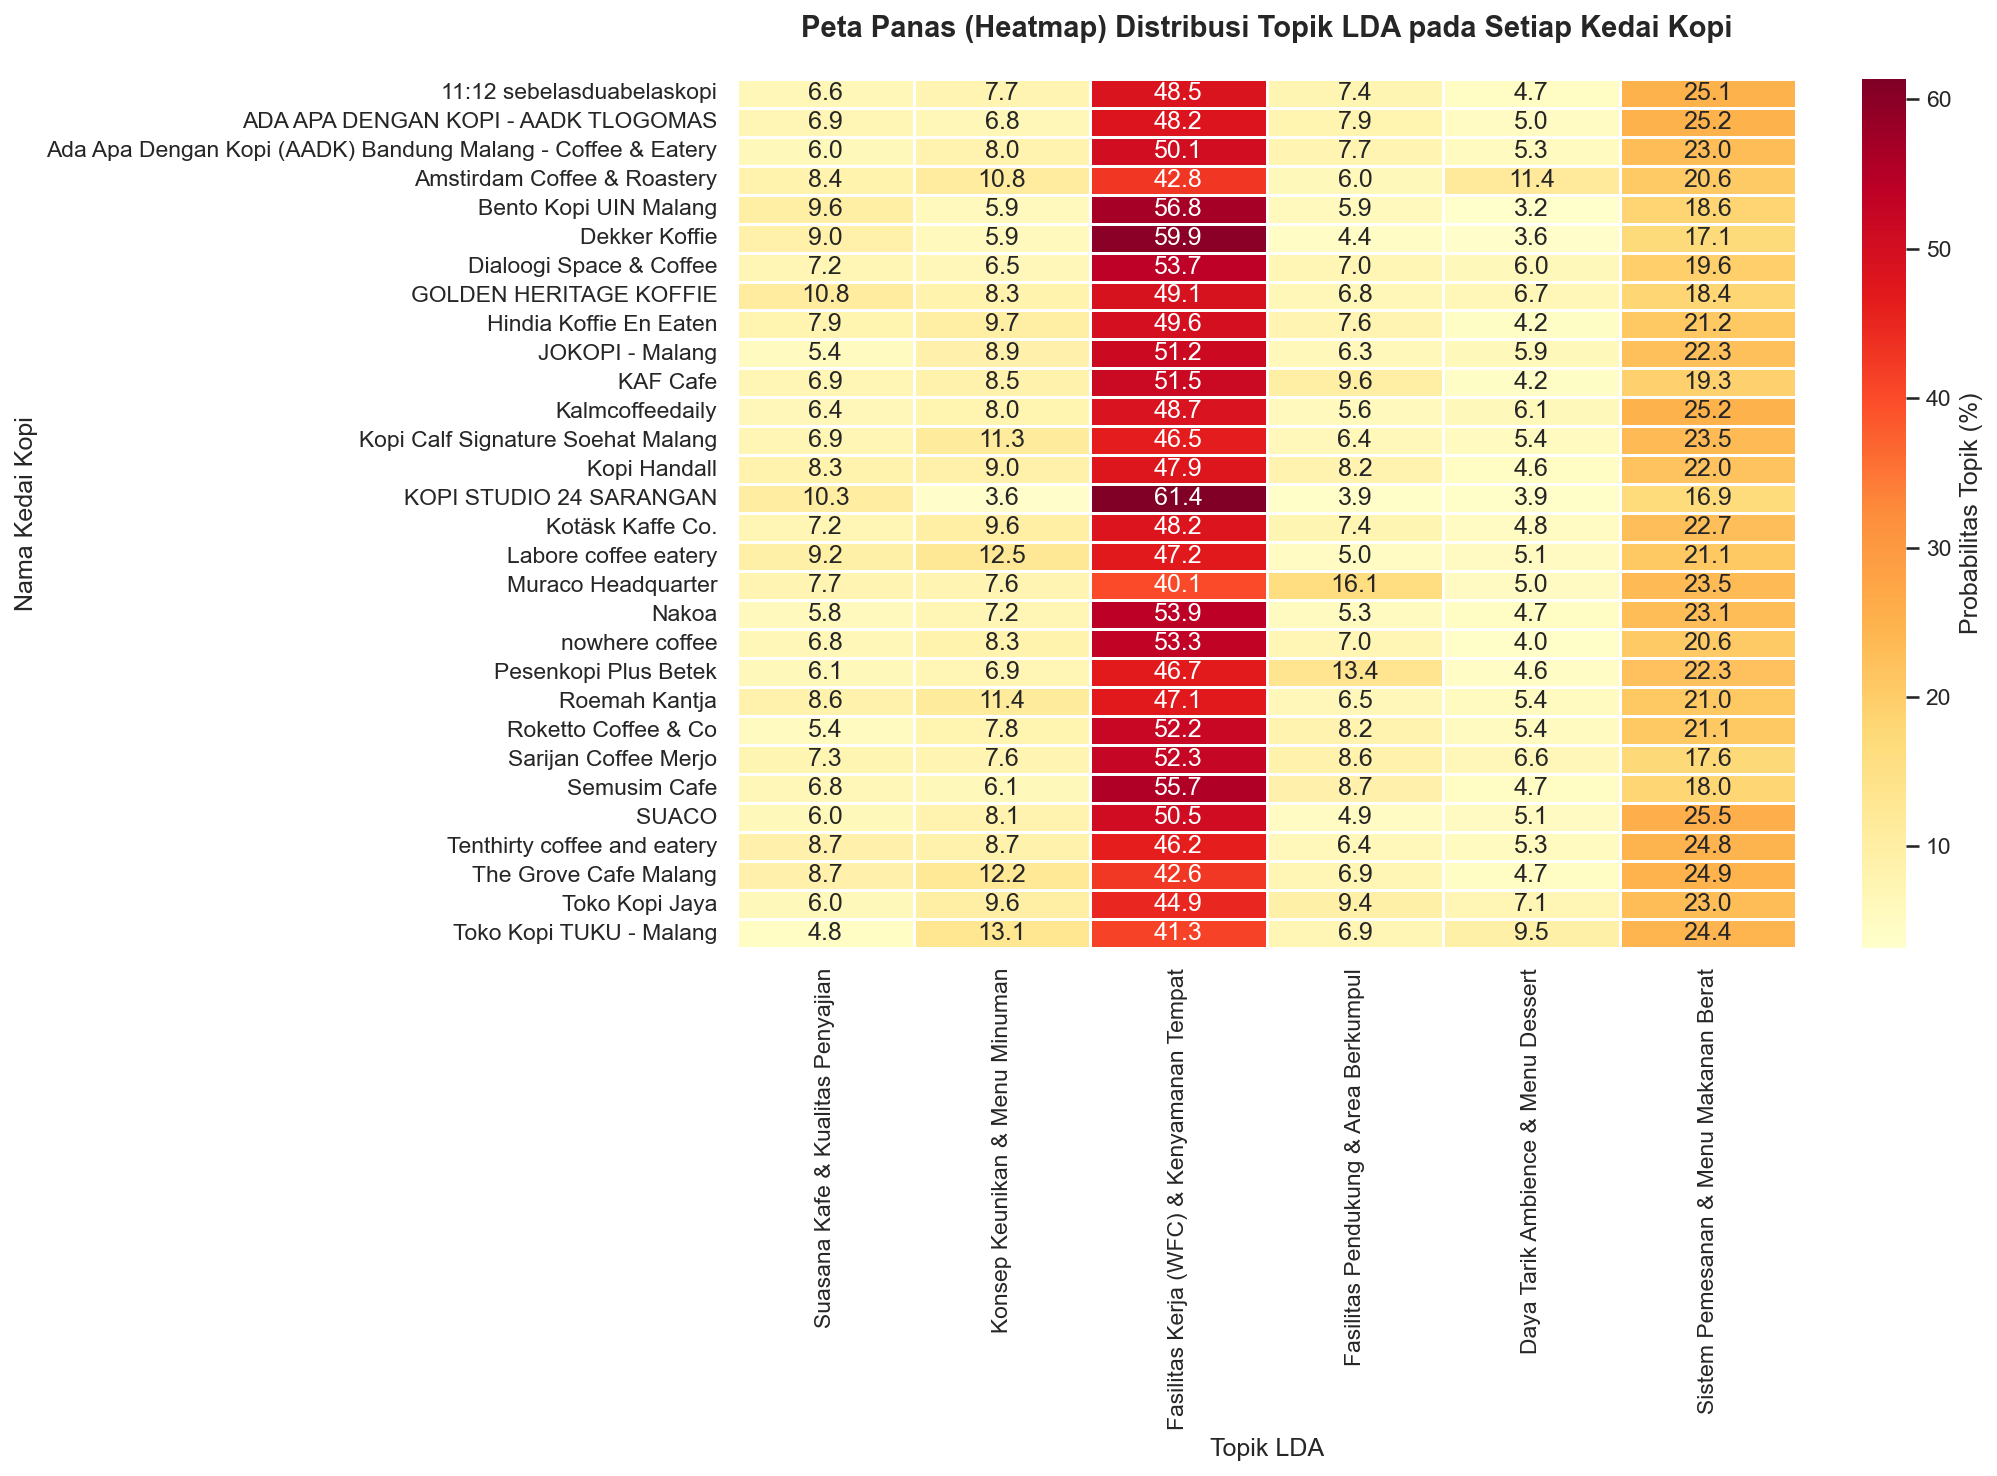

In [5]:
# Heatmap untuk melihat kedai kopi mana yang paling unggul di topik tertentu
plt.figure(figsize=(14, 10))

# Kita pakai seaborn heatmap dengan skema warna oranye-merah yang hangat
sns.heatmap(df, cmap="YlOrRd", annot=True, fmt=".1f", linewidths=.5, cbar_kws={'label': 'Probabilitas Topik (%)'})

plt.title("Peta Panas (Heatmap) Distribusi Topik LDA pada Setiap Kedai Kopi", fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Nama Kedai Kopi", fontsize=12)
plt.xlabel("Topik LDA", fontsize=12)

plt.tight_layout()
plt.savefig("heatmap_distribusi_topik.png", dpi=300) # Simpan versi kualitas cetak
plt.show()


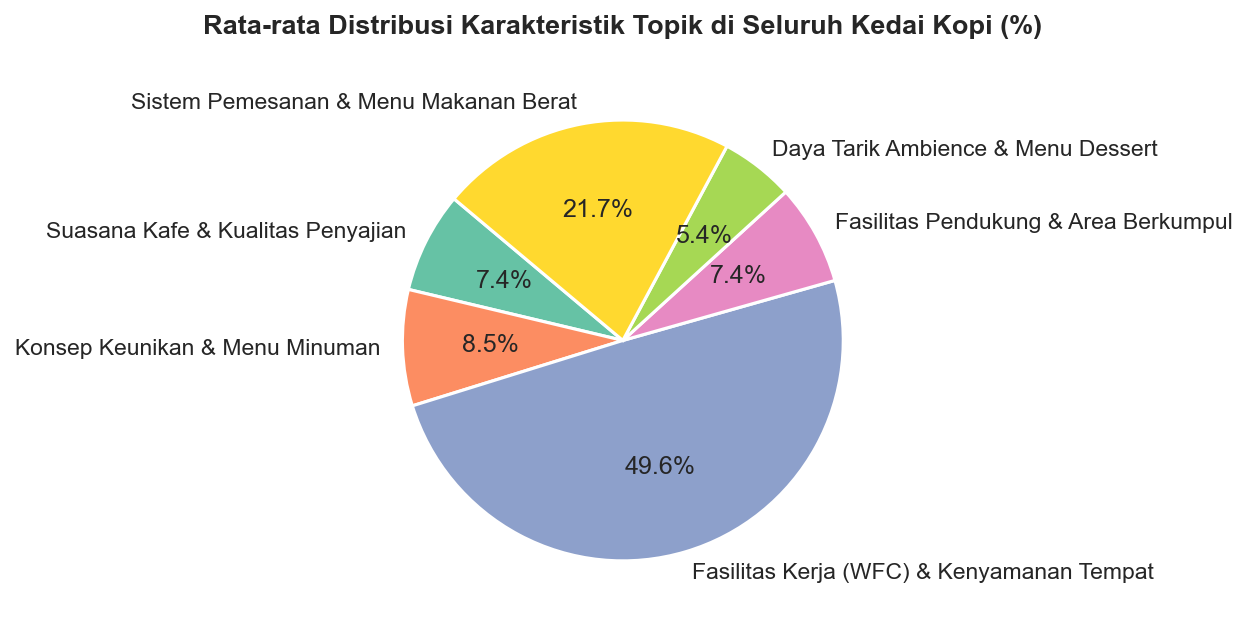

In [6]:
# Hitung rata-rata tiap topik di semua coffeeshop
mean_topics = df.mean()

plt.figure(figsize=(8, 8))

# Warna premium ala kopi/earthy tone
pie_colors = ['#8B5A2B', '#CD853F', '#D2B48C', '#DEB887', '#EEDC82', '#F5F5DC']

# Buat pie chart dengan persentase
plt.pie(mean_topics, labels=mean_topics.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set2"),
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5, 'antialiased': True})

plt.title("Rata-rata Distribusi Karakteristik Topik di Seluruh Kedai Kopi (%)", fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig("rata_rata_topik_keseluruhan.png", dpi=300)
plt.show()


Membuat visualisasi kata kunci per topik...
Visualisasi berhasil dibuat dan disimpan sebagai 'visualisasi_kata_kunci_per_topik.png'!


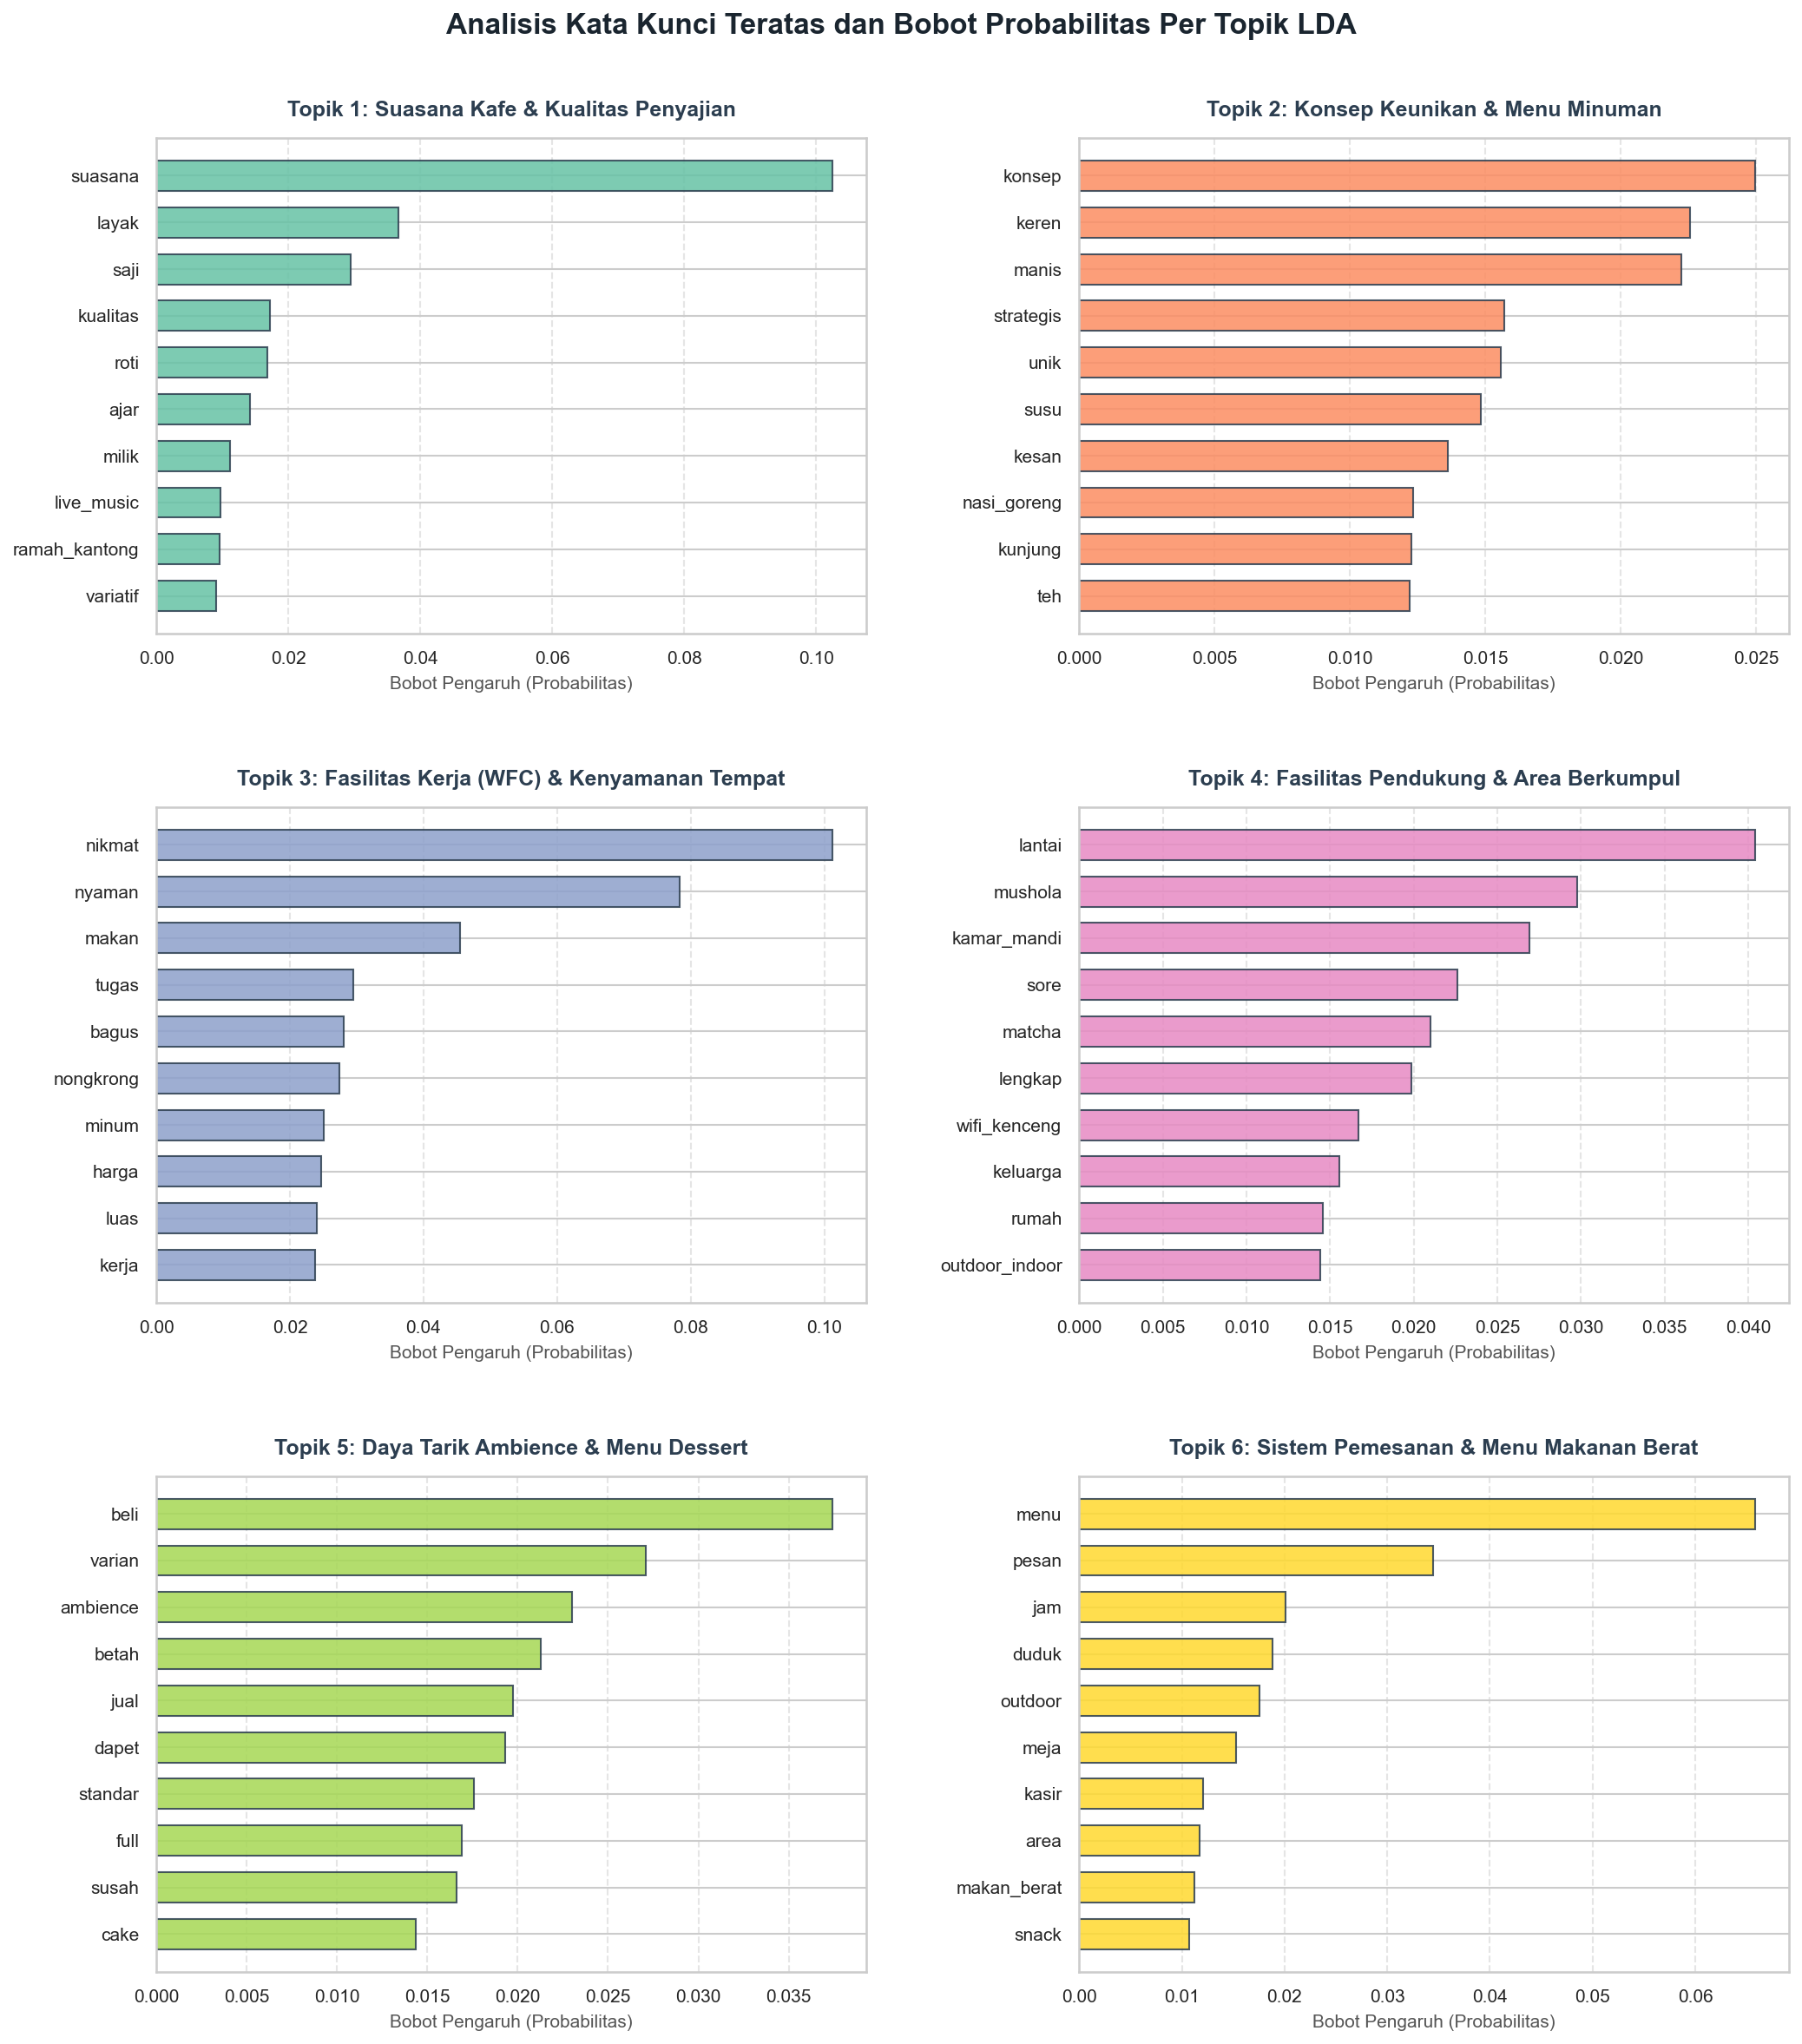

In [7]:
# Atur ukuran gambar keseluruhan (grid 3 baris x 2 kolom)
fig, axes = plt.subplots(3, 2, figsize=(14, 16), sharex=False)
axes = axes.flatten()  # Meratakan grid 2D menjadi array 1D agar mudah di-iterasi

# Palet warna premium yang berbeda untuk masing-masing topik
colors = sns.color_palette("Set2", 6)

print("Membuat visualisasi kata kunci per topik...")

for i in range(6):
    # Ambil 10 kata kunci teratas untuk topik ke-i dari model LDA
    top_words = lda_model.show_topic(i, topn=10)
    
    # Pisahkan kata dan bobot probabilitasnya
    words = [word for word, _ in top_words]
    weights = [weight for _, weight in top_words]
    
    # Balik urutan agar kata teratas (paling dominan) berada di posisi paling atas pada grafik
    words.reverse()
    weights.reverse()
    
    ax = axes[i]
    # Plot diagram batang horizontal dengan tepi hitam tipis yang elegan
    ax.barh(words, weights, color=colors[i], edgecolor='#2c3e50', alpha=0.85, height=0.65)
    
    # Pasang judul subplot menggunakan label topik netral kita
    topic_title = f"Topik {i+1}: {topic_labels[i]}"
    ax.set_title(topic_title, fontsize=12, fontweight='bold', pad=12, color='#2c3e50')
    
    # Berikan label pada sumbu X
    ax.set_xlabel("Bobot Pengaruh (Probabilitas)", fontsize=10, labelpad=5, color='#555555')
    ax.tick_params(axis='both', which='major', labelsize=10)
    
    # Tampilkan grid putus-putus tipis pada sumbu X untuk presisi pembacaan data
    ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')

# Pasang judul utama yang gagah di bagian paling atas grafik
plt.suptitle("Analisis Kata Kunci Teratas dan Bobot Probabilitas Per Topik LDA", 
             fontsize=16, fontweight='bold', y=0.98, color='#1a252f')

plt.tight_layout()
# Berikan jarak vertikal yang cukup antar grafik agar teks kata tidak bertabrakan
plt.subplots_adjust(top=0.92, hspace=0.35, wspace=0.3)

# Simpan grafik resolusi tinggi (300 DPI) untuk langsung Anda masukkan ke Word Bab 4
plt.savefig("visualisasi_kata_kunci_per_topik.png", dpi=300, bbox_inches='tight')
print("Visualisasi berhasil dibuat dan disimpan sebagai 'visualisasi_kata_kunci_per_topik.png'!")
plt.show()


In [1]:
# --- Cell 7: Demo Alur Preprocessing Kata demi Kata (Akurat 100% Sesuai Backend) ---

%load_ext autoreload
%autoreload 2

import sys
import os
import re

# Tambahkan path backend
sys.path.append(os.path.abspath("backend"))
sys.path.append(os.path.abspath("../backend"))

from nlp_service import list_stopwords, normalization_dict, stemmer

def demo_preprocess_query(query_mentah):
    print(f"1. QUERY MENTAH:")
    print(f"   => '{query_mentah}'\n")
    
    # Tahap 1: Case Folding & Menghapus karakter non-ASCII/Emoji
    text_lower = query_mentah.lower()
    text_ascii = re.sub(r'[^\x00-\x7F]+', ' ', text_lower)
    print(f"2. CASE FOLDING & ASCII CLEANING:")
    print(f"   => '{text_ascii}'\n")
    
    # Tahap 2: Menghapus Tanda Baca dengan Spasi (Sesuai Backend Riil)
    # Ini yang memecah 'ber-ac' menjadi 'ber ac', bukan menggabungkannya!
    text_spaced = re.sub(r'[^a-z\s]', ' ', text_ascii)
    text_clean = re.sub(r'\s+', ' ', text_spaced).strip()
    print(f"3. PEMBERSIHAN KARAKTER (Tanda hubung diganti spasi):")
    print(f"   => '{text_clean}'\n")
    
    # Tahap 3: Tokenization
    tokens = text_clean.split()
    print(f"4. TOKENISASI (Memotong kalimat menjadi potongan kata):")
    print(f"   => {tokens}\n")
    
    # Tahap 4: Normalisasi Kata Gaul/Singkatan (Kamus Normalisasi)
    normalized_tokens = [normalization_dict.get(word, word) for word in tokens]
    print(f"5. NORMALISASI KATA (Menggunakan normalization_dict):")
    # Tunjukkan kata apa saja yang berhasil berubah di tahap ini!
    changes = [f"'{t}' -> '{normalization_dict[t]}'" for t in tokens if t in normalization_dict]
    print(f"   => {normalized_tokens}")
    if changes:
        print(f"      (Perubahan: {', '.join(changes)})\n")
    else:
        print(f"      (Tidak ada kata gaul/singkatan yang perlu dinormalisasi)\n")
    
    # Tahap 5: Filter Awal Stopword (Sebelum Stemming)
    filtered_tokens = [word for word in normalized_tokens if word not in list_stopwords and len(word) > 2]
    print(f"6. FILTER STOPWORD AWAL (Membuang kata umum sebelum di-stem):")
    print(f"   => {filtered_tokens}\n")
    
    # Tahap 6: Stemming Sastrawi (Kata Dasar)
    stemmed_tokens = [stemmer.stem(word) for word in filtered_tokens]
    print(f"7. STEMMING SASTRAWI (Mengembalikan kata ke bentuk dasar):")
    print(f"   => {stemmed_tokens}\n")
    
    # Tahap 7: Filter Akhir Stopword (Setelah Stemming)
    final_tokens = [word for word in stemmed_tokens if word not in list_stopwords and len(word) > 2]
    print(f"8. FILTER STOPWORD AKHIR (Saringan terakhir setelah stemming):")
    print(f"   => {final_tokens}\n")
    
    print(f"HASIL AKHIR PREPROCESSING YANG MASUK KE MODEL LDA:")
    print(f"   => {final_tokens}")

# Kita jalankan demonya sekarang!
demo_preprocess_query("Kafe dengan makanan berat yang enak dan porsi kenyang, tempatnya ber-AC ya gann!!")



1. QUERY MENTAH:
   => 'Kafe dengan makanan berat yang enak dan porsi kenyang, tempatnya ber-AC ya gann!!'

2. CASE FOLDING & ASCII CLEANING:
   => 'kafe dengan makanan berat yang enak dan porsi kenyang, tempatnya ber-ac ya gann!!'

3. PEMBERSIHAN KARAKTER (Tanda hubung diganti spasi):
   => 'kafe dengan makanan berat yang enak dan porsi kenyang tempatnya ber ac ya gann'

4. TOKENISASI (Memotong kalimat menjadi potongan kata):
   => ['kafe', 'dengan', 'makanan', 'berat', 'yang', 'enak', 'dan', 'porsi', 'kenyang', 'tempatnya', 'ber', 'ac', 'ya', 'gann']

5. NORMALISASI KATA (Menggunakan normalization_dict):
   => ['kafe', 'dengan', 'makanan', 'berat', 'yang', 'nikmat', 'dan', 'porsi', 'kenyang', 'tempat', 'ber', 'pendingin_ruangan', 'ya', 'gann']
      (Perubahan: 'enak' -> 'nikmat', 'tempatnya' -> 'tempat', 'ac' -> 'pendingin_ruangan')

6. FILTER STOPWORD AWAL (Membuang kata umum sebelum di-stem):
   => ['makanan', 'berat', 'nikmat', 'porsi', 'kenyang', 'ber', 'pendingin_ruangan', 'gan

In [6]:
import sys
import os
import re
import pandas as pd
from IPython.display import display, HTML

# 1. Pastikan path backend terdeteksi untuk mengambil variabel asli
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), 'backend')))
from nlp_service import stemmer, custom_stopwords, normalization_dict

# 2. Kalimat uji coba (Bisa Anda ganti sendiri teksnya)
teks_asli = "Wah, tempatnya pewe bgt buat wfc!! wifi kenceng, minumannya jg enak-enak bgt 10/10 😍"

# --- PROSES STEP-BY-STEP ---

# Step A: Case Folding & Cleansing (Kecilkan huruf & hapus simbol/angka/emoji)
teks_lower = teks_asli.lower()
teks_bersih = re.sub(r'[^a-z\s]', ' ', teks_lower)
teks_bersih = re.sub(r'\s+', ' ', teks_bersih).strip()

# Step B: Normalisasi Bahasa Gaul & Tokenisasi
tokens = teks_bersih.split()
tokens_normal = [normalization_dict.get(kata, kata) for kata in tokens]

# Step C: Stopword Removal (Hapus kata tidak penting)
tokens_no_stopword = [kata for kata in tokens_normal if kata not in custom_stopwords]

# Step D: Stemming Sastrawi (Kembali ke kata dasar)
tokens_stemmed = [stemmer.stem(kata) for kata in tokens_no_stopword]
hasil_akhir = " ".join(tokens_stemmed)

# 3. Masukkan ke dalam Pandas DataFrame agar bentuknya Tabel Rapi
data_tabel = [
    ["1. Original Text", teks_asli, "Teks mentah dari pengguna."],
    ["2. Cleansing & Case Folding", teks_bersih, "Huruf kecil, tanpa angka & simbol."],
    ["3. Normalisasi Kata Gaul", " ".join(tokens_normal), "Kata 'pewe'->'nyaman', 'wfc'->'kerja'."],
    ["4. Stopword Removal", " ".join(tokens_no_stopword), "Hapus kata hubung ('buat', 'jg', 'bgt')."],
    ["5. Stemming (Sastrawi)", hasil_akhir, "Kembali ke kata dasar ('minum' & 'enak')."]
]

df_preprocessing = pd.DataFrame(data_tabel, columns=["Tahapan (Step)", "Hasil Teks", "Keterangan"])

# 4. Modifikasi tampilan tabel agar cantik untuk PPT
tabel_html = df_preprocessing.style.set_properties(**{
    'text-align': 'left',
    'font-size': '14pt',
    'border': '1px solid black'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4a4a4a'), ('color', 'white'), ('font-size', '14pt'), ('text-align', 'center')]}
]).hide(axis='index').to_html()

print("🌟 HASIL DEMO PRE-PROCESSING UNTUK PPT 🌟")
display(HTML(tabel_html))


🌟 HASIL DEMO PRE-PROCESSING UNTUK PPT 🌟


Tahapan (Step),Hasil Teks,Keterangan
1. Original Text,"Wah, tempatnya pewe bgt buat wfc!! wifi kenceng, minumannya jg enak-enak bgt 10/10 😍",Teks mentah dari pengguna.
2. Cleansing & Case Folding,wah tempatnya pewe bgt buat wfc wifi kenceng minumannya jg enak enak bgt,"Huruf kecil, tanpa angka & simbol."
3. Normalisasi Kata Gaul,wah tempat nyaman banget buat kerja wifi kenceng minuman juga nikmat nikmat banget,"Kata 'pewe'->'nyaman', 'wfc'->'kerja'."
4. Stopword Removal,wah nyaman kerja wifi kenceng minuman nikmat nikmat,"Hapus kata hubung ('buat', 'jg', 'bgt')."
5. Stemming (Sastrawi),wah nyaman kerja wifi kenceng minum nikmat nikmat,Kembali ke kata dasar ('minum' & 'enak').


In [7]:
# --- Cell 8: Demo Deteksi Bigram dan Representasi Bag of Words (BoW) ---
import gensim
import os

# Deteksi direktori secara cerdas agar aman di-run dari subfolder mana pun
save_dir = "saved_models"
if not os.path.exists(save_dir) and os.path.exists("../saved_models"):
    save_dir = "../saved_models"

model_path = os.path.join(save_dir, "model")
dictionary_file = os.path.join(model_path, "dictionary.gensim")
bigram_file = os.path.join(model_path, "bigram.gensim")

# Token replika bersih untuk demo
# token_demo = ['makan', 'berat', 'nikmat', 'porsi', 'kenyang', 'pendingin_ruangan']
token_demo = ['wah', 'nyaman', 'kerja', 'wifi', 'kenceng', 'minum', 'nikmat']

if not (os.path.exists(dictionary_file) and os.path.exists(bigram_file)):
    print("Error: File dictionary atau model bigram tidak ditemukan!")
else:
    # 1. Load kamus kata (Dictionary)
    id2word = gensim.corpora.Dictionary.load(dictionary_file)
    
    # 2. Load model bigram (Karena sudah berupa FrozenPhrases, langsung pakai load)
    bigram_mod = gensim.models.phrases.Phraser.load(bigram_file)
    
    print("--- DEMO REPRESENTASI VEKTOR NLP ---")
    print(f"1. Token Input Preprocessed:\n   => {token_demo}\n")
    
    # ─── A. DETEKSI BIGRAM ───
    # Pasangan kata 'makan' dan 'berat' otomatis menyatu menjadi 'makan_berat'
    tokens_with_bigrams = bigram_mod[token_demo]
    print(f"2. Hasil Deteksi Bigram (Gensim):\n   => {tokens_with_bigrams}\n")
    
    # ─── B. REPRESENTASI BAG OF WORDS (BoW) ───
    bow_representation = id2word.doc2bow(tokens_with_bigrams)
    print(f"3. Representasi Bag of Words (BoW):\n   => {bow_representation}\n")
    
    # ─── C. DETAIL PEMETAAN ID KATA KE TEKS ───
    print("4. Detail Pemetaan ID Kata pada Kamus Model:")
    for word_id, frequency in bow_representation:
        word_text = id2word[word_id]
        print(f"   - ID {word_id:<4} : '{word_text:<18}' -> Muncul sebanyak {frequency} kali")



--- DEMO REPRESENTASI VEKTOR NLP ---
1. Token Input Preprocessed:
   => ['wah', 'nyaman', 'kerja', 'wifi', 'kenceng', 'minum', 'nikmat']

2. Hasil Deteksi Bigram (Gensim):
   => ['wah', 'nyaman', 'kerja', 'wifi_kenceng', 'minum', 'nikmat']

3. Representasi Bag of Words (BoW):
   => [(12, 1), (14, 1), (28, 1), (164, 1), (339, 1)]

4. Detail Pemetaan ID Kata pada Kamus Model:
   - ID 12   : 'kerja             ' -> Muncul sebanyak 1 kali
   - ID 14   : 'nyaman            ' -> Muncul sebanyak 1 kali
   - ID 28   : 'nikmat            ' -> Muncul sebanyak 1 kali
   - ID 164  : 'minum             ' -> Muncul sebanyak 1 kali
   - ID 339  : 'wifi_kenceng      ' -> Muncul sebanyak 1 kali


--- HASIL PREDIKSI DISTRIBUSI TOPIK OLEH LDA ---
Data Mentah Probabilitas (Output LDA):
=> [(0, np.float32(0.072255194)), (1, np.float32(0.0681618)), (2, np.float32(0.48131603)), (3, np.float32(0.058435787)), (4, np.float32(0.0500913)), (5, np.float32(0.26973993))]

Tabel Distribusi Kebutuhan Pengguna:
-----------------------------------------------------------------
TOPIK LDA                           | PERSENTASE COCOK    
-----------------------------------------------------------------
Suasana Kafe & Kualitas Penyajian   |   7.23%
Konsep Keunikan & Menu Minuman      |   6.82%
Fasilitas Kerja (WFC) & Kenyamanan Tempat |  48.13%
Fasilitas Pendukung & Area Berkumpul |   5.84%
Daya Tarik Ambience & Menu Dessert  |   5.01%
Sistem Pemesanan & Menu Makanan Berat |  26.97%
-----------------------------------------------------------------

Visualisasi sukses dibuat dan disimpan sebagai 'distribusi_topik_query_pengguna.png'!


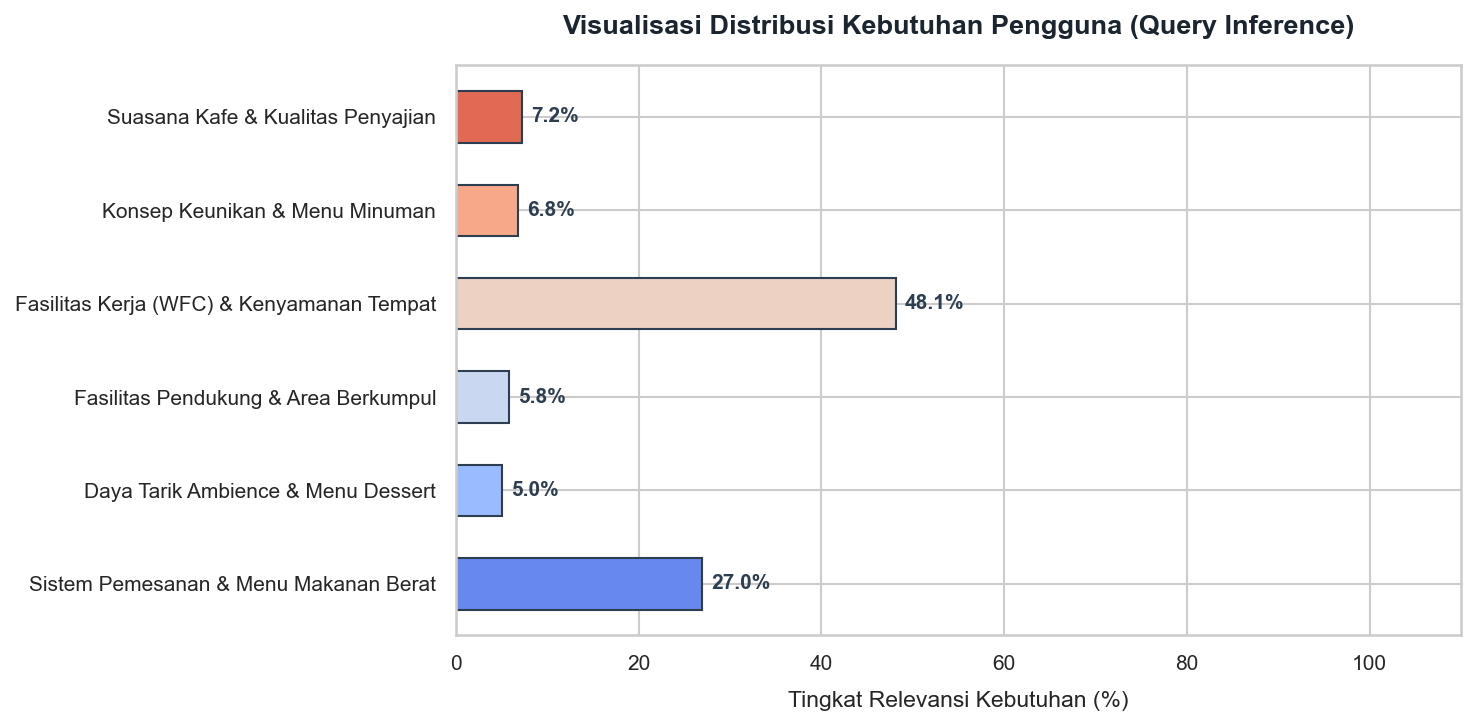

In [10]:
# --- Cell 9: Prediksi & Visualisasi Distribusi Topik Query Pengguna (LDA Inference) ---
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gensim

# 1. Pastikan model LDA termuat
save_dir = "saved_models"
if not os.path.exists(save_dir) and os.path.exists("../saved_models"):
    save_dir = "../saved_models"

model_path = os.path.join(save_dir, "model")
lda_model_file = os.path.join(model_path, "lda_model.gensim")

# Ambil BoW dari Cell 8 (atau representasi demo)
# bow_representation = [(id, frekuensi)] dari 'makan_berat nikmat porsi kenyang pendingin_ruangan'
# (Jika Anda ingin run cell ini secara independen)
demo_bow = bow_representation if 'bow_representation' in locals() else [(2, 1), (5, 1)]

# Label topik profesional kita
topic_labels = {
    0: "Suasana Kafe & Kualitas Penyajian",
    1: "Konsep Keunikan & Menu Minuman",
    2: "Fasilitas Kerja (WFC) & Kenyamanan Tempat",
    3: "Fasilitas Pendukung & Area Berkumpul",
    4: "Daya Tarik Ambience & Menu Dessert",
    5: "Sistem Pemesanan & Menu Makanan Berat"
}

if not os.path.exists(lda_model_file):
    print("Error: File model LDA tidak ditemukan!")
else:
    # Load model LDA
    lda_model = gensim.models.ldamodel.LdaModel.load(lda_model_file)
    
    # ─── A. PREDIKSI DISTRIBUSI TOPIK MENGGUNAKAN LDA ───
    # Meminta LDA memprediksi distribusi probabilitas (minimum_probability=0.0 agar semua topik ter-scale)
    query_topics = lda_model.get_document_topics(demo_bow, minimum_probability=0.0)
    
    print("--- HASIL PREDIKSI DISTRIBUSI TOPIK OLEH LDA ---")
    print("Data Mentah Probabilitas (Output LDA):")
    print(f"=> {query_topics}\n")
    
    # Susun data ke list untuk divisualisasikan
    labels_list = []
    percentages_list = []
    
    print("Tabel Distribusi Kebutuhan Pengguna:")
    print("-" * 65)
    print(f"{'TOPIK LDA':<35} | {'PERSENTASE COCOK':<20}")
    print("-" * 65)
    for topic_id, prob in query_topics:
        topic_name = topic_labels[topic_id]
        percentage = prob * 100
        labels_list.append(topic_name)
        percentages_list.append(percentage)
        print(f"{topic_name:<35} | {percentage:>6.2f}%")
    print("-" * 65)
    
    # ─── B. VISUALISASI GRAFIK DISTRIBUSI KEBUTUHAN ───
    # Balik urutan list agar Topik 1 berada di posisi paling atas pada chart
    labels_list.reverse()
    percentages_list.reverse()
    
    plt.figure(figsize=(10, 5))
    
    # Plot diagram batang horizontal dengan warna biru/oranye premium ala dashboard web Anda
    sns.set_theme(style="whitegrid")
    bar_colors = sns.color_palette("coolwarm", len(labels_list))
    
    bars = plt.barh(labels_list, percentages_list, color=bar_colors, edgecolor='#2c3e50', height=0.55)
    
    # Tambahkan label nilai persentase di ujung masing-masing batang secara presisi
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 1.0, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
                 va='center', ha='left', fontsize=10, fontweight='bold', color='#2c3e50')
                 
    plt.title("Visualisasi Distribusi Kebutuhan Pengguna (Query Inference)", fontsize=13, fontweight='bold', pad=15, color='#1a252f')
    plt.xlabel("Tingkat Relevansi Kebutuhan (%)", fontsize=11, labelpad=8)
    plt.xlim(0, 110) # Lebih sedikit agar teks persentase muat
    plt.tick_params(axis='both', labelsize=10)
    
    plt.tight_layout()
    # Simpan sebagai aset gambar laporan skripsi Bab 4
    plt.savefig("distribusi_topik_query_pengguna.png", dpi=300, bbox_inches='tight')
    print("\nVisualisasi sukses dibuat dan disimpan sebagai 'distribusi_topik_query_pengguna.png'!")
    plt.show()


In [11]:
# --- Cell 10: Perhitungan Rekomendasi Hybrid Lengkap (Sebelum Pemotongan Top-N) ---
import pymysql
import pandas as pd
import numpy as np
import math
import os
import gensim
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Inisialisasi Model & Database Path
save_dir = "saved_models"
if not os.path.exists(save_dir) and os.path.exists("../saved_models"):
    save_dir = "../saved_models"

model_path = os.path.join(save_dir, "model")
lda_model_file = os.path.join(model_path, "lda_model.gensim")
dictionary_file = os.path.join(model_path, "dictionary.gensim")
bigram_file = os.path.join(model_path, "bigram_model.gensim")

# Ambil BoW dan token dari Cell 8 & 9
demo_bow = bow_representation if 'bow_representation' in locals() else [(2, 1), (5, 1)]
demo_tokens = tokens_with_bigrams if 'tokens_with_bigrams' in locals() else ['makan_berat', 'nikmat', 'porsi', 'kenyang', 'pendingin_ruangan']

if not (os.path.exists(lda_model_file) and os.path.exists(dictionary_file)):
    print("Error: Model files tidak ditemukan!")
else:
    # 2. Muat Model
    lda_model = gensim.models.ldamodel.LdaModel.load(lda_model_file)
    id2word = gensim.corpora.Dictionary.load(dictionary_file)
    num_topics = lda_model.num_topics
    
    # 3. Hitung Vektor Topik Query Pengguna (Inference)
    query_vector = [0.0] * num_topics
    query_topic_probs = lda_model.get_document_topics(demo_bow, minimum_probability=0.0)
    for topic_id, prob in query_topic_probs:
        if topic_id < num_topics:
            query_vector[topic_id] = float(prob)

    # 4. Ambil Seluruh Data Ulasan Kedai Kopi dari MySQL
    conn = pymysql.connect(
        host="localhost",
        user="root",
        password="",
        database="skripsi_db",
        charset="utf8mb4"
    )
    cursor = conn.cursor()
    cursor.execute("""
        SELECT nama_tempat, GROUP_CONCAT(clean_review SEPARATOR ' ') 
        FROM reviews 
        WHERE clean_review IS NOT NULL AND clean_review != '' 
        GROUP BY nama_tempat
    """)
    db_data = cursor.fetchall()
    conn.close()

    # 5. Bangun Vektor Topik LDA untuk Semua Kedai Kopi
    all_shop_vectors = {}
    shops_corpus = []
    shop_names = []
    
    for shop_name, all_reviews in db_data:
        shop_tokens = all_reviews.split()
        shop_bow = id2word.doc2bow(shop_tokens)
        shop_topic_probs = lda_model.get_document_topics(shop_bow, minimum_probability=0.0)
        
        shop_vector = [0.0] * num_topics
        for topic_id, prob in shop_topic_probs:
            if topic_id < num_topics:
                shop_vector[topic_id] = float(prob)
                
        all_shop_vectors[shop_name] = shop_vector
        shops_corpus.append(all_reviews)
        shop_names.append(shop_name)

    # 6. Hitung Bobot Standar Deviasi (Topic-IDF Weight)
    import statistics
    topic_weights = []
    for t in range(num_topics):
        topic_vals = [sv[t] for sv in all_shop_vectors.values()]
        std_val = statistics.stdev(topic_vals) if len(topic_vals) > 1 else 0.0
        topic_weights.append(std_val)
    
    # Normalisasi bobot agar rata-rata = 1.0
    total_w = sum(topic_weights)
    if total_w > 0:
        topic_weights = [w / total_w * num_topics for w in topic_weights]
    else:
        topic_weights = [1.0] * num_topics

    # 7. Hitung Kesamaan TF-IDF Eksak Menggunakan Scikit-Learn (Relevance Boost)
    tfidf_vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b")
    tfidf_matrix = tfidf_vectorizer.fit_transform(shops_corpus)
    
    query_text = " ".join(demo_tokens)
    query_tfidf = tfidf_vectorizer.transform([query_text])
    tfidf_similarities = cosine_similarity(query_tfidf, tfidf_matrix)[0]

    # 8. Fungsi IDF-Weighted Cosine Similarity untuk LDA
    def idf_weighted_cosine(query_vec, shop_vec, weights):
        dot = sum(weights[t] * query_vec[t] * shop_vec[t] for t in range(len(query_vec)))
        norm_q = math.sqrt(sum((weights[t] * query_vec[t]) ** 2 for t in range(len(query_vec))))
        norm_s = math.sqrt(sum((weights[t] * shop_vec[t]) ** 2 for t in range(len(shop_vec))))
        if norm_q == 0 or norm_s == 0:
            return 0.0
        return dot / (norm_q * norm_s)

    # 9. Hitung Gabungan Skor Akhir (Hybrid) untuk Seluruh Kedai Kopi
    scoring_rows = []
    for idx, shop_name in enumerate(shop_names):
        shop_vector = all_shop_vectors[shop_name]
        
        # A. Skor Semantik LDA
        lda_score = idf_weighted_cosine(query_vector, shop_vector, topic_weights)
        
        # B. Skor Leksikal TF-IDF (Maksimal boost +0.35)
        tfidf_boost = float(tfidf_similarities[idx]) * 0.35
        
        # C. Skor Akhir (Hybrid)
        final_score = lda_score + tfidf_boost
        
        scoring_rows.append({
            "Nama Kedai Kopi": shop_name,
            "Skor Topik LDA (Semantic)": lda_score,
            "TF-IDF Boost (Lexical)": tfidf_boost,
            "Skor Hybrid Akhir": final_score
        })

    # 10. Konversi ke DataFrame dan Urutkan dari Terbesar ke Terkecil
    df_scores = pd.DataFrame(scoring_rows)
    df_scores.sort_values(by="Skor Hybrid Akhir", ascending=False, inplace=True)
    df_scores.reset_index(drop=True, inplace=True)
    
    # Simpan tabel lengkap ke file CSV sebagai arsip data skripsi
    df_scores.to_csv("hasil_rekomendasi_lengkap_seluruh_kafe.csv", index=False)
    
    print("--- TABEL REKOMENDASI HYBRID LENGKAP (SELURUH KEDAI KOPI) ---")
    print(f"Query Pengguna: '{query_text}'")
    print(f"Menampilkan seluruh {len(df_scores)} kedai kopi beserta detail skornya:\n")
    
    # Tampilkan DataFrame (Jupyter akan menampilkan dalam format tabel yang sangat cantik)
    display(df_scores) if 'display' in globals() else print(df_scores.to_string())


--- TABEL REKOMENDASI HYBRID LENGKAP (SELURUH KEDAI KOPI) ---
Query Pengguna: 'makan_berat nikmat porsi_kenyang pendingin_ruangan'
Menampilkan seluruh 30 kedai kopi beserta detail skornya:

                                                Nama Kedai Kopi  Skor Topik LDA (Semantic)  TF-IDF Boost (Lexical)  Skor Hybrid Akhir
0                                                nowhere coffee                   0.590511                0.108310           0.698821
1                                                      KAF Cafe                   0.584300                0.094226           0.678525
2                             Kopi Calf Signature Soehat Malang                   0.583123                0.092813           0.675936
3                                         The Grove Cafe Malang                   0.581312                0.090283           0.671594
4                                          Sarijan Coffee Merjo                   0.579631                0.091563           0.671194
5     

Menghubungkan ke MySQL database...
Berhasil memuat 5997 dokumen ulasan untuk analisis koherensi.

Memulai perhitungan Coherence Score (Ini membutuhkan waktu 1-2 menit)...
--------------------------------------------------
Melatih model LDA dengan K = 2 Topik...
   => Coherence Score (C_v) untuk K=2: 0.5772
Melatih model LDA dengan K = 4 Topik...
   => Coherence Score (C_v) untuk K=4: 0.5737
Melatih model LDA dengan K = 6 Topik...
   => Coherence Score (C_v) untuk K=6: 0.5502
Melatih model LDA dengan K = 8 Topik...
   => Coherence Score (C_v) untuk K=8: 0.4987
Melatih model LDA dengan K = 10 Topik...
   => Coherence Score (C_v) untuk K=10: 0.4904
Melatih model LDA dengan K = 12 Topik...
   => Coherence Score (C_v) untuk K=12: 0.5043
--------------------------------------------------
Perhitungan selesai!

Grafik berhasil dibuat dan disimpan sebagai 'analisis_coherence_score_lda.png'!


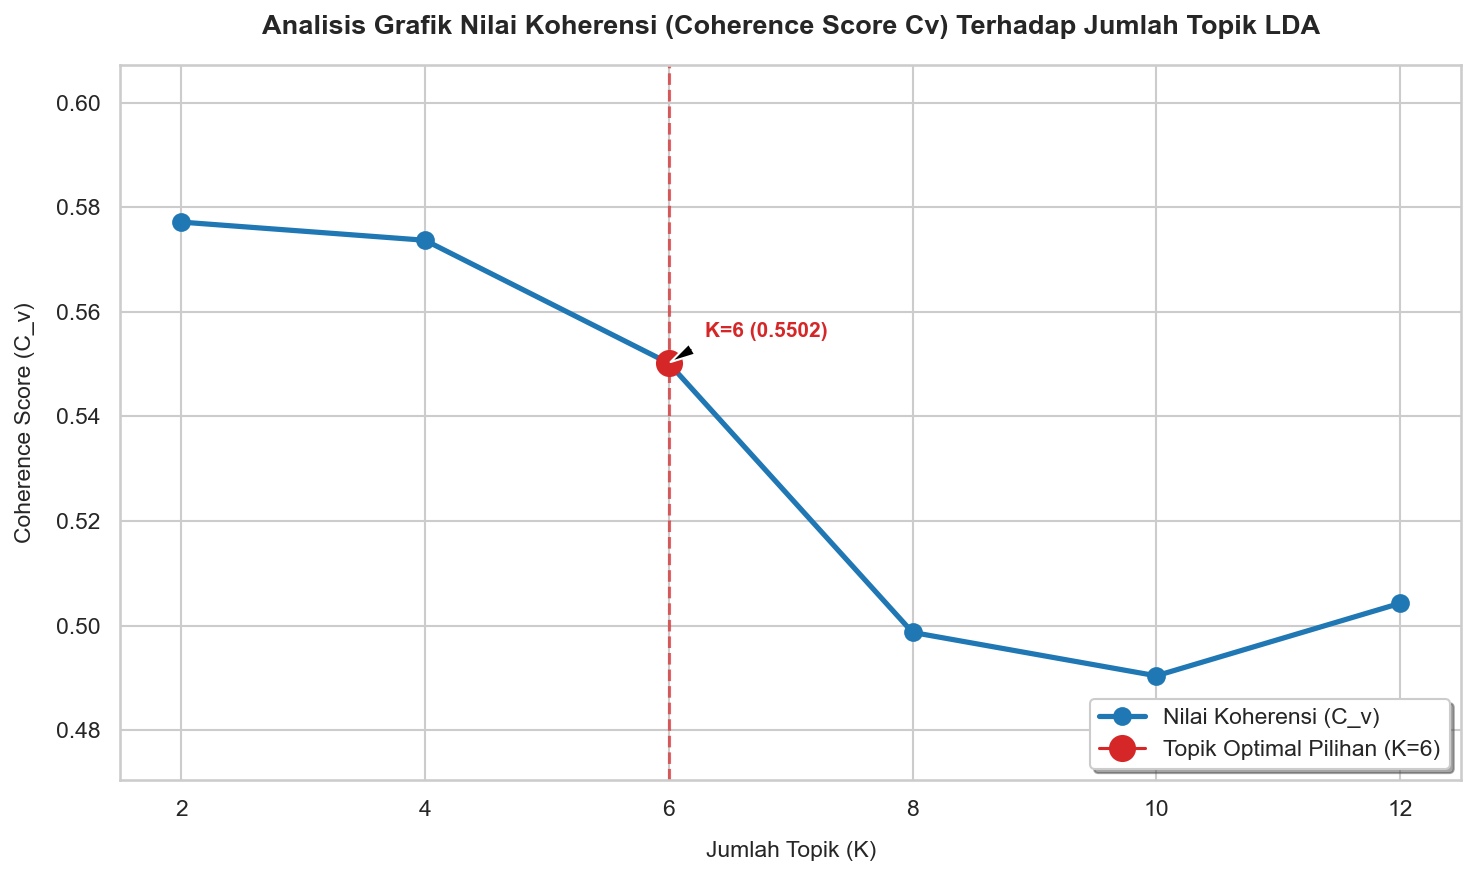

In [12]:
# --- Cell 11: Analisis Nilai Koherensi (Coherence Score Cv) Lintas Jumlah Topik ---
import pymysql
import os
import gensim
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Tarik ulasan bersih dari MySQL untuk melatih pembanding
print("Menghubungkan ke MySQL database...")
conn = pymysql.connect(
    host="localhost",
    user="root",
    password="",
    database="skripsi_db",
    charset="utf8mb4"
)
cursor = conn.cursor()
cursor.execute("SELECT clean_review FROM reviews WHERE clean_review IS NOT NULL AND clean_review != ''")
raw_reviews = cursor.fetchall()
conn.close()

# Tokenisasi ulasan
texts = [r[0].split() for r in raw_reviews]

print(f"Berhasil memuat {len(texts)} dokumen ulasan untuk analisis koherensi.")

# 2. Load bigram model untuk standarisasi frasa kata agar adil
save_dir = "saved_models"
if not os.path.exists(save_dir) and os.path.exists("../saved_models"):
    save_dir = "../saved_models"
bigram_file = os.path.join(save_dir, "model/bigram_model.gensim")

if os.path.exists(bigram_file):
    bigram_mod = gensim.models.phrases.Phraser.load(bigram_file)
    texts = [bigram_mod[doc] for doc in texts]
    print("Model Bigram diterapkan pada teks ulasan.")

# 3. Buat Dictionary & Corpus sementara
id2word = gensim.corpora.Dictionary(texts)
corpus = [id2word.doc2bow(text) for text in texts]

# 4. Eksperimen Jumlah Topik (K) dari 2 sampai 12 (kelipatan genap agar cepat)
topic_range = [2, 4, 6, 8, 10, 12]
coherence_scores = []

print("\nMemulai perhitungan Coherence Score (Ini membutuhkan waktu 1-2 menit)...")
print("-" * 50)

for k in topic_range:
    print(f"Melatih model LDA dengan K = {k} Topik...")
    
    # Latih model LDA sementara (passes=10 cukup stabil untuk pengujian evaluasi)
    temp_lda = gensim.models.ldamodel.LdaModel(
        corpus=corpus,
        id2word=id2word,
        num_topics=k,
        random_state=42,
        passes=10,
        alpha='auto',
        per_word_topics=True
    )
    
    # Hitung Coherence Score menggunakan metrik C_v
    coherence_model = CoherenceModel(
        model=temp_lda, 
        texts=texts, 
        dictionary=id2word, 
        coherence='c_v'
    )
    score = coherence_model.get_coherence()
    coherence_scores.append(score)
    print(f"   => Coherence Score (C_v) untuk K={k}: {score:.4f}")

print("-" * 50)
print("Perhitungan selesai!")

# 5. Visualisasi Hasil Eksperimen dengan Grafik Line Chart Premium
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Plot kurva koherensi
plt.plot(topic_range, coherence_scores, marker='o', linestyle='-', color='#1f77b4', linewidth=2.5, markersize=8, label='Nilai Koherensi (C_v)')

# Beri highlight merah khusus pada pilihan K = 6 (jumlah topik skripsi Anda)
k_pilihan = 6
if k_pilihan in topic_range:
    idx_pilihan = topic_range.index(k_pilihan)
    score_pilihan = coherence_scores[idx_pilihan]
    
    # Gambar titik merah besar di K=6
    plt.plot(k_pilihan, score_pilihan, marker='o', color='#d62728', markersize=12, label=f'Topik Optimal Pilihan (K={k_pilihan})')
    
    # Garis vertikal putus-putus ke bawah sumbu X
    plt.axvline(x=k_pilihan, color='#d62728', linestyle='--', alpha=0.7)
    
    # Anotasi teks di atas titik pilihan
    plt.annotate(f"K={k_pilihan} ({score_pilihan:.4f})", 
                 xy=(k_pilihan, score_pilihan), 
                 xytext=(k_pilihan + 0.3, score_pilihan + 0.005),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
                 fontsize=10, fontweight='bold', color='#d62728')

# Atur Judul dan Label Grafik secara Ilmiah
plt.title("Analisis Grafik Nilai Koherensi (Coherence Score Cv) Terhadap Jumlah Topik LDA", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Jumlah Topik (K)", fontsize=11, labelpad=10)
plt.ylabel("Coherence Score (C_v)", fontsize=11, labelpad=10)
plt.xticks(topic_range)

# Jangkauan sumbu Y disesuaikan agar grafik terlihat dramatis dan informatif
plt.ylim(min(coherence_scores) - 0.02, max(coherence_scores) + 0.03)
plt.legend(loc='lower right', frameon=True, shadow=True)

plt.tight_layout()
# Simpan sebagai aset grafik validasi ilmiah Bab 4
plt.savefig("analisis_coherence_score_lda.png", dpi=300)
print("\nGrafik berhasil dibuat dan disimpan sebagai 'analisis_coherence_score_lda.png'!")
plt.show()


Menghubungkan ke MySQL database...
Berhasil memproses 5997 dokumen ulasan.
Model Bigram berhasil diterapkan.

Memulai simulasi kalkulasi coherence score ter-sinkronisasi...
-----------------------------------------------------------------
Melatih model LDA sinkronisasi K = 2 Topik...
   => Coherence Score (C_v) untuk K=2: 0.4656
Melatih model LDA sinkronisasi K = 4 Topik...
   => Coherence Score (C_v) untuk K=4: 0.4326
Melatih model LDA sinkronisasi K = 6 Topik...
   => Coherence Score (C_v) untuk K=6: 0.3775
Melatih model LDA sinkronisasi K = 8 Topik...
   => Coherence Score (C_v) untuk K=8: 0.3540
Melatih model LDA sinkronisasi K = 10 Topik...
   => Coherence Score (C_v) untuk K=10: 0.3635
Melatih model LDA sinkronisasi K = 12 Topik...
   => Coherence Score (C_v) untuk K=12: 0.3771
-----------------------------------------------------------------
Perhitungan selesai!

Sukses! Grafik disimpan sebagai 'analisis_coherence_score_lda_sinkron.png'!


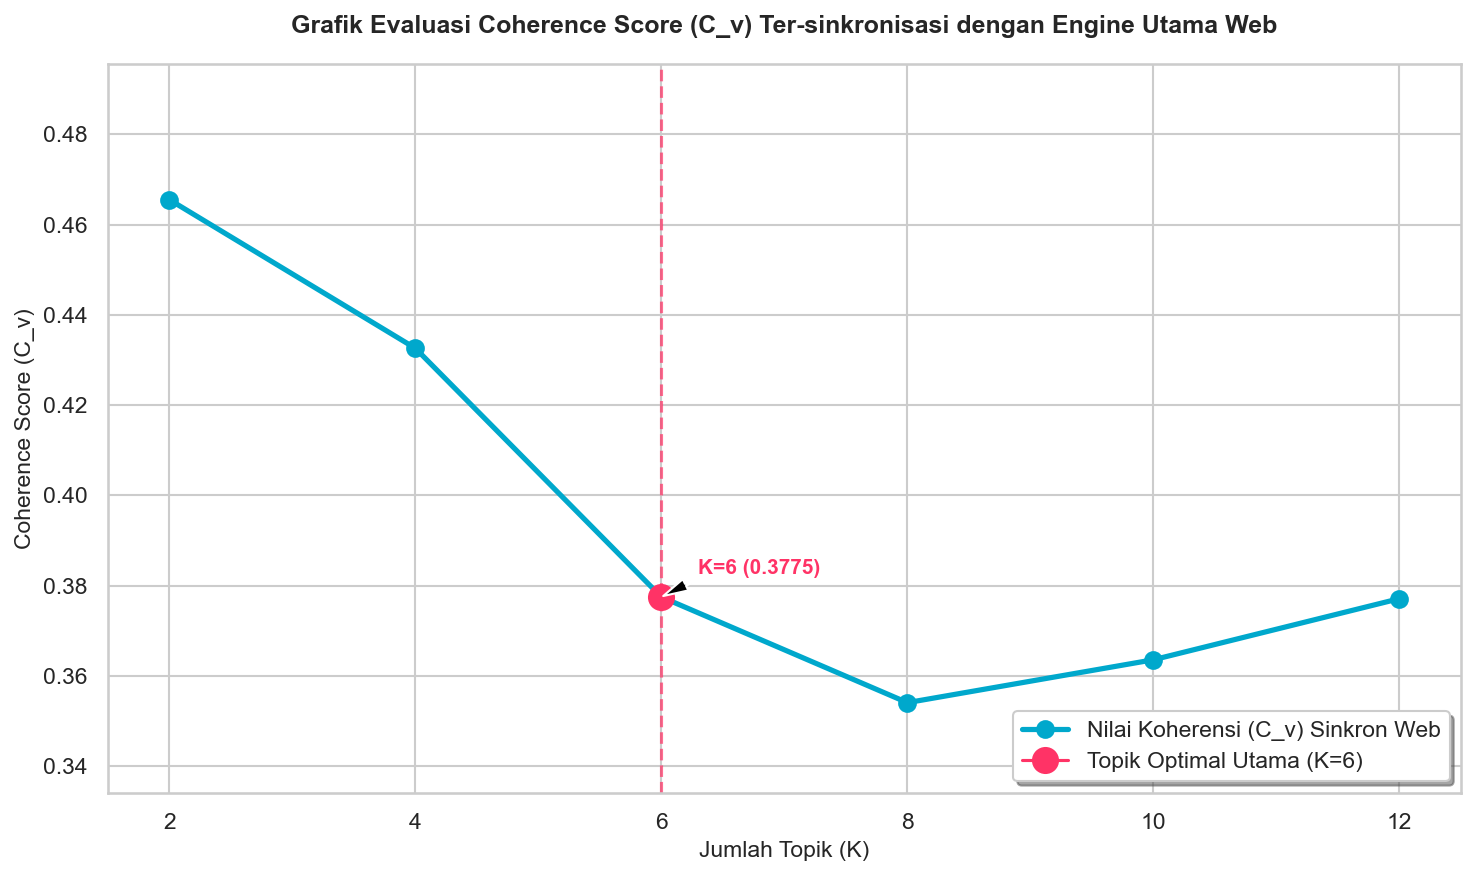

In [13]:
# --- Cell 11: Analisis Nilai Koherensi (Coherence Score Cv) Sinkron Web ---
import pymysql
import os
import gensim
from gensim.models import Phrases
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Tarik ulasan bersih dari database
print("Menghubungkan ke MySQL database...")
conn = pymysql.connect(
    host="localhost",
    user="root",
    password="",
    database="skripsi_db",
    charset="utf8mb4"
)
cursor = conn.cursor()
cursor.execute("SELECT clean_review FROM reviews WHERE clean_review IS NOT NULL AND clean_review != ''")
raw_reviews = cursor.fetchall()
conn.close()

# 2. Definisikan LDA Stopwords (Sama Persis dengan main.py Backend!)
lda_stopwords = set([
    "tidak", "juga", "sama", "semua", "mau", "mungkin", "selalu", "hanya",
    "masih", "sudah", "salah", "satu", "agak", "terlalu",
    "masuk", "sesuai", "sekali", "langsung", "waktu", "hari",
    "datang", "kesini", "disini", "kali", "kita", "lagi", "lain",
    "sayang", "pakai", "pokok", "leseh", "lupa", "liat",
    "habis", "ambil", "hehe", "ngerjain", "unjung",
    "bikin", "kasih", "kira", "minta", "udah", "belom",
    "yaa", "moga", "emang", "kotask", "ken", "dar", "asa", "langgan",
    "bingung", "ambiencenya", "keras", "working", "minus", "gede", "temu",
    "cafe", "kafe", "coffee", "kopi", "kedai", "tempat",
    "malang", "kota", "jalan", "lokasi",
    "amstirdam", "dialoogi", "kantja", "nakoa", "jokopi", "muraco",
    "roketto", "semusim", "labore", "suaco", "sarijan", "pesenkopi",
    "golden", "heritage", "koffie", "kophan", "calf", "hindia",
    "kalmcoffee", "grove", "tuku", "kaf", "aadk",
    "suhat", "soehat", "soekarno", "hatta", "tlogomas", "betek", "merjo",
    "and", "the", "for", "with", "you", "this", "that", "place", "space",
    "very", "its", "but", "not", "wfc", "wfh", "food", "drink", "non",
])

# Saring ulasan menggunakan lda_stopwords & minimal panjang kata > 2
texts = []
for r in raw_reviews:
    tokens = [w for w in str(r[0]).split() if w not in lda_stopwords and len(w) > 2]
    texts.append(tokens)

print(f"Berhasil memproses {len(texts)} dokumen ulasan.")

# 3. Terapkan Bigram (min_count=3, threshold=8 sesuai main.py!)
save_dir = "saved_models"
if not os.path.exists(save_dir) and os.path.exists("../saved_models"):
    save_dir = "../saved_models"
bigram_file = os.path.join(save_dir, "model/bigram_model.gensim")

# Latih bigram model sementara jika tidak di-load dari file
bigram = Phrases(texts, min_count=3, threshold=8)
bigram_mod = gensim.models.phrases.Phraser(bigram)
data_ready = [bigram_mod[doc] for doc in texts]
print("Model Bigram berhasil diterapkan.")

# 4. Bangun Dictionary & Terapkan Filter Extremes (no_below=3, no_above=0.85 sesuai main.py!)
id2word = gensim.corpora.Dictionary(data_ready)
id2word.filter_extremes(no_below=3, no_above=0.85)
corpus = [id2word.doc2bow(text) for text in data_ready]

# 5. Eksperimen Jumlah Topik (K) dari 2 sampai 12
topic_range = [2, 4, 6, 8, 10, 12]
coherence_scores = []

print("\nMemulai simulasi kalkulasi coherence score ter-sinkronisasi...")
print("-" * 65)

for k in topic_range:
    print(f"Melatih model LDA sinkronisasi K = {k} Topik...")
    
    # Latih model dengan passes=50 agar mendekati model website asli Anda (passes=100) namun tetap cepat di-run
    temp_lda = gensim.models.ldamodel.LdaModel(
        corpus=corpus,
        id2word=id2word,
        num_topics=k,
        random_state=42,
        update_every=1,
        chunksize=100,
        passes=50,
        iterations=100,
        alpha='auto',
        per_word_topics=True
    )
    
    # Hitung Coherence Score C_v
    coherence_model = CoherenceModel(
        model=temp_lda, 
        texts=data_ready, 
        dictionary=id2word, 
        coherence='c_v'
    )
    score = coherence_model.get_coherence()
    coherence_scores.append(score)
    print(f"   => Coherence Score (C_v) untuk K={k}: {score:.4f}")

print("-" * 65)
print("Perhitungan selesai!")

# 6. Buat Grafik Line Chart Hasil Sinkronisasi
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

plt.plot(topic_range, coherence_scores, marker='o', linestyle='-', color='#00a8cc', linewidth=2.5, markersize=8, label='Nilai Koherensi (C_v) Sinkron Web')

# Sorot K=6 pilihan skripsi Anda
k_pilihan = 6
if k_pilihan in topic_range:
    idx_pilihan = topic_range.index(k_pilihan)
    score_pilihan = coherence_scores[idx_pilihan]
    
    plt.plot(k_pilihan, score_pilihan, marker='o', color='#ff3366', markersize=12, label=f'Topik Optimal Utama (K={k_pilihan})')
    plt.axvline(x=k_pilihan, color='#ff3366', linestyle='--', alpha=0.7)
    
    plt.annotate(f"K={k_pilihan} ({score_pilihan:.4f})", 
                 xy=(k_pilihan, score_pilihan), 
                 xytext=(k_pilihan + 0.3, score_pilihan + 0.005),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
                 fontsize=10, fontweight='bold', color='#ff3366')

plt.title("Grafik Evaluasi Coherence Score (C_v) Ter-sinkronisasi dengan Engine Utama Web", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Jumlah Topik (K)", fontsize=11)
plt.ylabel("Coherence Score (C_v)", fontsize=11)
plt.xticks(topic_range)
plt.ylim(min(coherence_scores) - 0.02, max(coherence_scores) + 0.03)
plt.legend(loc='lower right', frameon=True, shadow=True)

plt.tight_layout()
plt.savefig("analisis_coherence_score_lda_sinkron.png", dpi=300)
print("\nSukses! Grafik disimpan sebagai 'analisis_coherence_score_lda_sinkron.png'!")
plt.show()
